# ME 455
Author: Conor Hayes

## Problem 2
Solve the following 2D optimization problem for the variable x = [x1, x2]:
```
[see assignment pdf]
```

using gradient descent with Armijo line search. The line search process in each iteration is
summarized in the pseudocode below. Note that, in practice, the parameter ↵ should be small
(between 10^-4 to 10^-2) and the parameter $\beta$ should be between 0.2 to 0.8. Use the initial
guess of the variable x = [-4, -2], use the following parameters $\gamma_0 = 1$, $\alpha = 10^{-4}$, $\beta = 0.5$,
run for 100 iterations in total.

Turn in: A plot showing the trajectory of the iterations over the contour of the objective
function, see the example ﬁgure above.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    x1, x2 = x
    return 0.26 * (x1**2 + x2**2) - 0.46 * x1 * x2

def grad_f(x):
    x1, x2 = x
    return np.array([0.52 * x1 - 0.46 * x2, 0.52 * x2 - 0.46 * x1])

def armijo_line_search(x, grad, gamma0, alpha, beta):
    gamma = gamma0
    z = -grad
    while f(x + gamma * z) > f(x) + alpha * gamma * grad @ z:
        gamma *= beta
    return gamma

# gradient descent with Armijo line search
gamma0, alpha, beta = 1.0, 1e-4, 0.5
n_iters = 100

x = np.array([-4.0, -2.0])
trajectory = [x.copy()]
for k in range(n_iters):
    grad = grad_f(x)
    gamma = armijo_line_search(x, grad, gamma0, alpha, beta)
    x = x - gamma * grad
    trajectory.append(x.copy())

trajectory = np.array(trajectory)

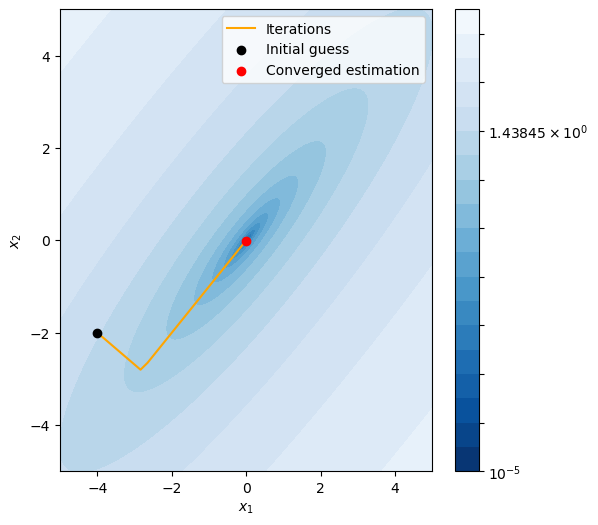

In [3]:
x1_grid = np.linspace(-5, 5, 200)
x2_grid = np.linspace(-5, 5, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z = 0.26 * (X1**2 + X2**2) - 0.46 * X1 * X2

fig, ax = plt.subplots(figsize=(6, 6))
levels = np.logspace(-5, 2, 20)
cs = ax.contourf(X1, X2, np.abs(Z) + 1e-10, levels=levels, norm=plt.matplotlib.colors.LogNorm(),
                  cmap='Blues_r')
fig.colorbar(cs, ax=ax)

ax.plot(trajectory[:, 0], trajectory[:, 1], color='orange', label='Iterations')
ax.scatter(trajectory[0, 0], trajectory[0, 1], color='black', zorder=5, label='Initial guess')
ax.scatter(trajectory[-1, 0], trajectory[-1, 1], color='red', zorder=5, label='Converged estimation')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()
plt.show()

# Problem 3
Apply iLQR to the differential drive vehicle for a length of time T = $2\pi$ sec to track the desired trajectory subject to the dynamics:

```
[see assignment pdf]
```

Note that the desired trajectory corresponds to an infeasible trajectory for parallel park-
ing. A Python template for iLQR can be found here: https://drive.google.com/file/d/
1Br8DArJtnEZXjZok2aWh7PMVoTuRq1hc/view?usp=sharing, you should try di↵erent param-
eters and initial control trajectories to see their e↵ect on the optimal trajectory.

Turn in: Select three sets of different initial control trajectories and objective parameters,
with one of the initial control trajectories being [1, -0.5] for the whole horizon. For each set of
parameters, choose a convergence criterion and run the algorithm until convergence. For each
set of parameters, generate a plot with the following content (see the example below): (1)
The initial and converged system trajectory; (2) The optimal control signals; (3) Iterations
of the objective function value. Submit three such plots and include the parameters you use.

In [4]:
from scipy.integrate import solve_bvp

In [5]:
dt = 0.1
tsteps = 63  # T = 2*pi sec
x0 = np.array([0.0, 0.0, np.pi/2.0])


def xd_at(t):
    return np.array([2.0 * t / np.pi, 0.0, np.pi / 2.0])


def dyn(xt, ut):
    return np.array([np.cos(xt[2]) * ut[0], np.sin(xt[2]) * ut[0], ut[1]])


def get_A(t, xt, ut):
    return np.array([
        [0.0, 0.0, -np.sin(xt[2]) * ut[0]],
        [0.0, 0.0,  np.cos(xt[2]) * ut[0]],
        [0.0, 0.0,  0.0]
    ])


def get_B(t, xt, ut):
    return np.array([
        [np.cos(xt[2]), 0.0],
        [np.sin(xt[2]), 0.0],
        [0.0, 1.0]
    ])


def step(xt, ut):
    # RK4 integration
    k1 = dyn(xt, ut)
    k2 = dyn(xt + 0.5 * dt * k1, ut)
    k3 = dyn(xt + 0.5 * dt * k2, ut)
    k4 = dyn(xt + dt * k3, ut)
    return xt + dt / 6.0 * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def traj_sim(x0, ulist):
    tsteps = ulist.shape[0]
    x_traj = np.zeros((tsteps, 3))
    xt = x0.copy()
    for t in range(tsteps):
        xt_new = step(xt, ulist[t])
        x_traj[t] = xt_new.copy()
        xt = xt_new.copy()
    return x_traj


def total_cost(x_traj, u_traj, params):
    J = 0.0
    for t_idx in range(tsteps):
        dx = x_traj[t_idx] - xd_at(t_idx * dt)
        J += (dx @ params['Q_x'] @ dx + u_traj[t_idx] @ params['R_u'] @ u_traj[t_idx]) * dt
    dx_T = x_traj[-1] - xd_at((tsteps - 1) * dt)
    J += dx_T @ params['P1'] @ dx_T
    return J


def dldx(t, xt, ut, params):
    return 2.0 * params['Q_x'] @ (xt - xd_at(t))


def dldu(t, xt, ut, params):
    return 2.0 * params['R_u'] @ ut


def ilqr_iter(x0, u_traj, params):
    """
    :param x0: initial state of the system
    :param u_traj: current estimation of the optimal control trajectory
    :return: the descent direction for the control and the directional derivative DJ(u).v
    """
    Q_z, R_v = params['Q_z'], params['R_v']
    R_v_inv = np.linalg.inv(R_v)

    # forward simulate the state trajectory
    x_traj = traj_sim(x0, u_traj)

    # compute the variables needed for specifying the dynamics of z(t) and p(t)
    A_list = np.zeros((tsteps, 3, 3))
    B_list = np.zeros((tsteps, 3, 2))
    a_list = np.zeros((tsteps, 3))
    b_list = np.zeros((tsteps, 2))
    for t_idx in range(tsteps):
        t = t_idx * dt
        A_list[t_idx] = get_A(t, x_traj[t_idx], u_traj[t_idx])
        B_list[t_idx] = get_B(t, x_traj[t_idx], u_traj[t_idx])
        a_list[t_idx] = dldx(t, x_traj[t_idx], u_traj[t_idx], params)
        b_list[t_idx] = dldu(t, x_traj[t_idx], u_traj[t_idx], params)

    # terminal condition p(T) = Dm(x(T)) = 2 * P1 * (x(T) - xd(T))
    p1 = 2.0 * params['P1'] @ (x_traj[-1] - xd_at((tsteps - 1) * dt))

    def zp_dyn(t, zp):
        t_idx = int(np.clip(t / dt, 0, tsteps - 1))
        At = A_list[t_idx]
        Bt = B_list[t_idx]
        at = a_list[t_idx]
        bt = b_list[t_idx]

        M_11 = At
        M_12 = -0.5 * Bt @ R_v_inv @ Bt.T
        M_21 = -2.0 * Q_z
        M_22 = -At.T
        dyn_mat = np.block([
            [M_11, M_12],
            [M_21, M_22]
        ])

        m_1 = -0.5 * Bt @ R_v_inv @ bt
        m_2 = -at
        dyn_vec = np.hstack([m_1, m_2])

        return dyn_mat @ zp + dyn_vec

    def zp_dyn_list(t_list, zp_list):
        list_len = len(t_list)
        zp_dot_list = np.zeros((6, list_len))
        for _i in range(list_len):
            zp_dot_list[:, _i] = zp_dyn(t_list[_i], zp_list[:, _i])
        return zp_dot_list

    # boundary conditions: z(0) = 0, p(T) = p1
    def zp_bc(zp_0, zp_T):
        return np.hstack([zp_0[:3], zp_T[3:] - p1])

    ### The solver will say it does not converge, but the returned result
    ### is numerically accurate enough for our use
    tlist = np.arange(tsteps) * dt
    res = solve_bvp(
        zp_dyn_list, zp_bc, tlist, np.zeros((6, tsteps)),
        max_nodes=100
    )
    zp_traj = res.sol(tlist).T

    z_traj = zp_traj[:, :3]
    p_traj = zp_traj[:, 3:]

    # v(t) = -0.5 * Rv^-1 * (B(t)^T p(t) + b_u(t))
    v_traj = np.zeros((tsteps, 2))
    for _i in range(tsteps):
        v_traj[_i] = -0.5 * R_v_inv @ (B_list[_i].T @ p_traj[_i] + b_list[_i])

    # directional derivative DJ(u).v = int(a_x.z + b_u.v)dt + p1.z(T)
    descent_dot = p1 @ z_traj[-1]
    for _i in range(tsteps):
        descent_dot += (a_list[_i] @ z_traj[_i] + b_list[_i] @ v_traj[_i]) * dt

    return v_traj, descent_dot


def run_ilqr(init_u_traj, params, max_iters=100, tol=1e-3):
    u_traj = init_u_traj.copy()
    J_list = [total_cost(traj_sim(x0, u_traj), u_traj, params)]
    for it in range(max_iters):
        v_traj, descent_dot = ilqr_iter(x0, u_traj, params)

        # Armijo line search
        gamma, alpha, beta = 1.0, 1e-4, 0.5
        J_curr = J_list[-1]
        while True:
            u_new = u_traj + gamma * v_traj
            if total_cost(traj_sim(x0, u_new), u_new, params) <= J_curr + alpha * gamma * descent_dot:
                break
            gamma *= beta
            if gamma < 1e-8:
                break

        u_traj = u_traj + gamma * v_traj
        J_list.append(total_cost(traj_sim(x0, u_traj), u_traj, params))

        if abs(J_list[-1] - J_list[-2]) < tol:
            break

    return u_traj, np.array(J_list)


def plot_results(init_u_traj, u_traj, J_list, title):
    x_init = traj_sim(x0, init_u_traj)
    x_opt = traj_sim(x0, u_traj)
    tlist = np.arange(tsteps) * dt
    xd_traj = np.array([xd_at(t) for t in tlist])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(title)

    axes[0].plot(xd_traj[:, 0], xd_traj[:, 1], linestyle='--', color='gray', label='Desired')
    axes[0].plot(np.hstack([x0[0], x_init[:, 0]]), np.hstack([x0[1], x_init[:, 1]]),
                 color='C0', label='Initial')
    axes[0].plot(np.hstack([x0[0], x_opt[:, 0]]), np.hstack([x0[1], x_opt[:, 1]]),
                 color='C1', label='Converged')
    axes[0].set_xlabel('$x$')
    axes[0].set_ylabel('$y$')
    axes[0].set_title('System trajectory')
    axes[0].legend()

    axes[1].plot(tlist, u_traj[:, 0], label='$u_1$')
    axes[1].plot(tlist, u_traj[:, 1], label='$u_2$')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Control')
    axes[1].set_title('Optimal control signals')
    axes[1].legend()

    axes[2].plot(np.arange(len(J_list)), J_list)
    axes[2].set_xlabel('Iteration')
    axes[2].set_ylabel('Objective $J$')
    axes[2].set_title('Objective value')

    plt.tight_layout()
    plt.show()

Converged in 11 iterations, J = 45.0775


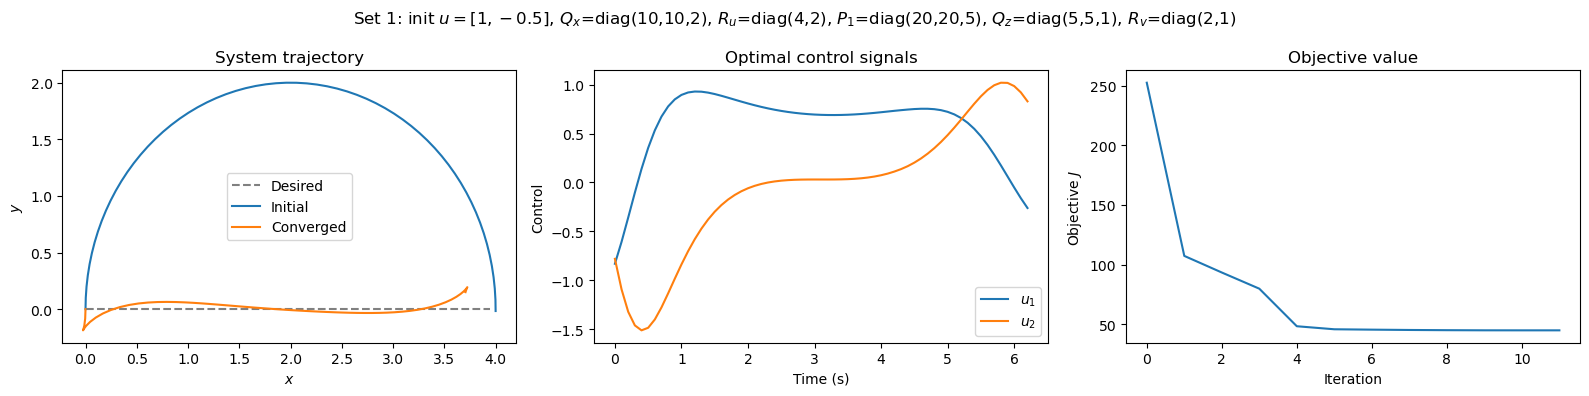

In [6]:
# Set 1: initial control [1, -0.5] for the whole horizon
params1 = {
    'Q_x': np.diag([10.0, 10.0, 2.0]),
    'R_u': np.diag([4.0, 2.0]),
    'P1': np.diag([20.0, 20.0, 5.0]),
    'Q_z': np.diag([5.0, 5.0, 1.0]),
    'R_v': np.diag([2.0, 1.0]),
}
init_u1 = np.tile(np.array([1.0, -0.5]), reps=(tsteps, 1))

u_opt1, J_list1 = run_ilqr(init_u1, params1)
print(f'Converged in {len(J_list1) - 1} iterations, J = {J_list1[-1]:.4f}')
plot_results(init_u1, u_opt1, J_list1,
             'Set 1: init $u = [1, -0.5]$, $Q_x$=diag(10,10,2), $R_u$=diag(4,2), '
             '$P_1$=diag(20,20,5), $Q_z$=diag(5,5,1), $R_v$=diag(2,1)')

Converged in 55 iterations, J = 49.7165


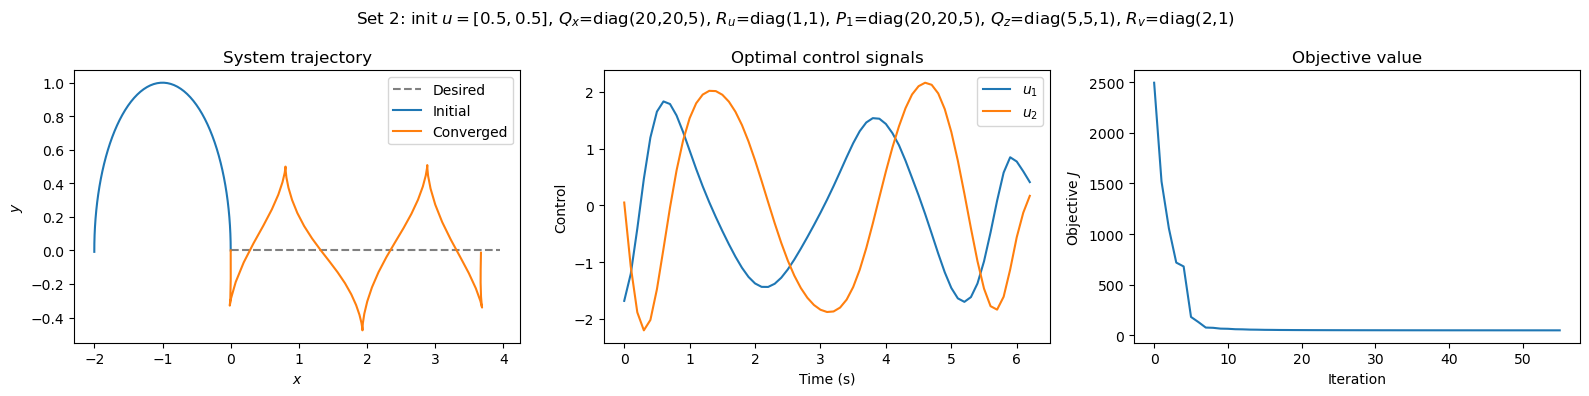

In [7]:
# Set 2: different initial control, heavier state weight and cheaper control cost
params2 = {
    'Q_x': np.diag([20.0, 20.0, 5.0]),
    'R_u': np.diag([1.0, 1.0]),
    'P1': np.diag([20.0, 20.0, 5.0]),
    'Q_z': np.diag([5.0, 5.0, 1.0]),
    'R_v': np.diag([2.0, 1.0]),
}
init_u2 = np.tile(np.array([0.5, 0.5]), reps=(tsteps, 1))

u_opt2, J_list2 = run_ilqr(init_u2, params2)
print(f'Converged in {len(J_list2) - 1} iterations, J = {J_list2[-1]:.4f}')
plot_results(init_u2, u_opt2, J_list2,
             'Set 2: init $u = [0.5, 0.5]$, $Q_x$=diag(20,20,5), $R_u$=diag(1,1), '
             '$P_1$=diag(20,20,5), $Q_z$=diag(5,5,1), $R_v$=diag(2,1)')

Converged in 73 iterations, J = 28.3571


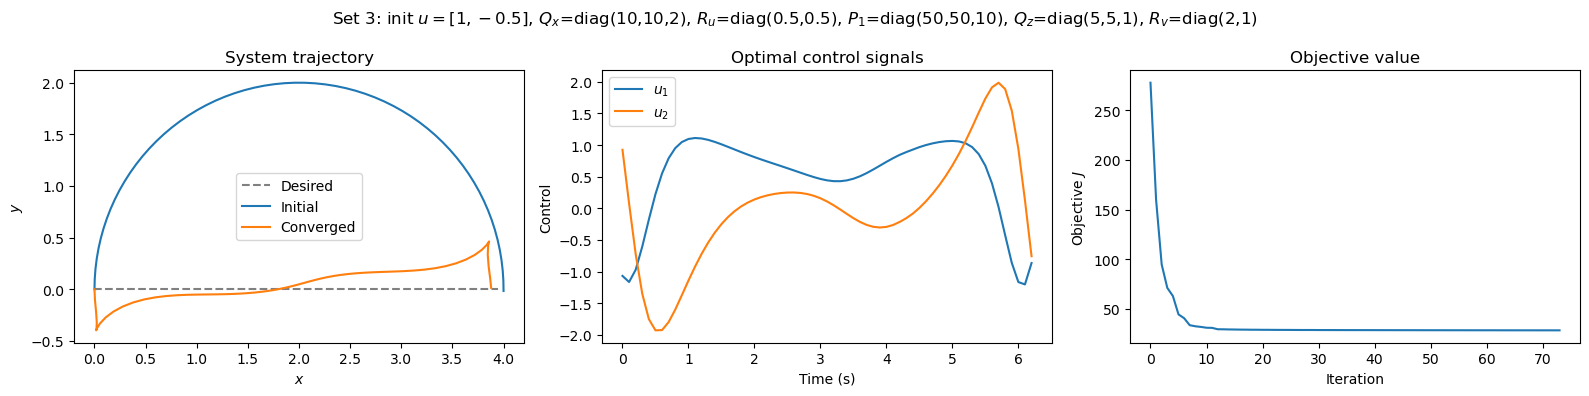

In [8]:
# Set 3: init [1, -0.5] with cheaper control and heavier terminal cost for tighter tracking
params3 = {
    'Q_x': np.diag([10.0, 10.0, 2.0]),
    'R_u': np.diag([0.5, 0.5]),
    'P1': np.diag([50.0, 50.0, 10.0]),
    'Q_z': np.diag([5.0, 5.0, 1.0]),
    'R_v': np.diag([2.0, 1.0]),
}
init_u3 = np.tile(np.array([1.0, -0.5]), reps=(tsteps, 1))

u_opt3, J_list3 = run_ilqr(init_u3, params3)
print(f'Converged in {len(J_list3) - 1} iterations, J = {J_list3[-1]:.4f}')
plot_results(init_u3, u_opt3, J_list3,
             'Set 3: init $u = [1, -0.5]$, $Q_x$=diag(10,10,2), $R_u$=diag(0.5,0.5), '
             '$P_1$=diag(50,50,10), $Q_z$=diag(5,5,1), $R_v$=diag(2,1)')